# Issue #11: EDA Visualizations – Charging Demand Patterns

**Input:** `acn_clean_sessions.csv` and `acn_flagged_sessions.csv` (Issue #9)  
**Outputs:** `eda_figures/*.png` (visualization set), `eda_visual_insights.md` (one insight per figure, numbers computed from the data)

Issue #10 holds the statistical tables and tests; this notebook turns the main patterns into charts. The same conventions are used so the two agree:
- **Policy regimes** (Lee, Li & Low, *ACN-Data*, e-Energy 2019): R1 free charging to 31 Aug 2018; R2 free with a 14 kWh default for unclaimed sessions, 1 Sep – 31 Oct; R3 paid ($0.12/kWh, unclaimed sessions stopped after 30 min) from 1 Nov. Dashed lines on time charts mark the two changes. Pooled charts mix regimes; where it matters, regimes are shown separately.
- **Per-day rates** divide by days with data; runs of 7+ consecutive zero-session days would be excluded as gaps.
- **Stay split** at the density valley between the short- and long-stay modes (same method as Issues #9 and #10).
- **Occupancy** includes the > 72 h sessions removed in Issue #9, because they occupied a charger.
- Every figure is followed by an **Insight** generated from the data shown, so the text cannot drift from the chart.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Markdown

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
FIG_DIR = "eda_figures"
os.makedirs(FIG_DIR, exist_ok=True)
LOCAL_TZ = "America/Los_Angeles"
DOW = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
C_WD, C_WE, C_ACC, C_GREY = "#2b6cb0", "#dd6b20", "#2f855a", "#a0aec0"

df = pd.read_csv("../acn_clean_sessions.csv")
for c in ["connectionTime", "disconnectTime", "doneChargingTime"]:
    df[c] = pd.to_datetime(df[c], utc=True)
    df[c + "_loc"] = df[c].dt.tz_convert(LOCAL_TZ).dt.tz_localize(None)
df["date"] = df["connectionTime_loc"].dt.normalize()
df["hour"] = df["connectionTime_loc"].dt.hour
df["dayofweek"] = df["connectionTime_loc"].dt.dayofweek
df["is_weekend"] = df["dayofweek"] >= 5
df["claimed"] = df["has_user_id"].astype(bool)
if "power_implausible" not in df.columns:
    df["power_implausible"] = False
df["done_ok"] = df["charging_h"].notna() & ~df["power_implausible"].astype(bool)
df["idle_h"] = np.where(df["done_ok"], (df["connected_h"] - df["charging_h"]).clip(lower=0), np.nan)

# Stay split at the density valley (same method as Issues #9/#10)
_h = df["connected_h"]
_counts, _edges = np.histogram(_h[(_h > 0) & (_h < 12)], bins=np.arange(0, 12.25, 0.25))
_smooth = pd.Series(_counts).rolling(5, center=True, min_periods=1).mean().values
_centres = (_edges[:-1] + _edges[1:]) / 2
_win = (_centres >= 1) & (_centres <= 10)
valley_h = float(_centres[_win][np.argmin(_smooth[_win])])
SHORT_STAY_H = round(valley_h * 2) / 2

# Policy regimes
POLICY_DATES = [pd.Timestamp("2018-09-01"), pd.Timestamp("2018-11-01")]
REGIMES = ["R1 free", "R2 free, 14 kWh default", "R3 paid"]
REG_COLORS = dict(zip(REGIMES, ["#4a5568", "#3182ce", "#e53e3e"]))
def regime_of(ts):
    return np.select([ts < POLICY_DATES[0], ts < POLICY_DATES[1]], REGIMES[:2], default=REGIMES[2])
df["regime"] = pd.Categorical(regime_of(df["connectionTime_loc"]), categories=REGIMES, ordered=True)

# Long (> 72 h) sessions removed in Issue #9: used for occupancy only
long_sessions = pd.DataFrame(columns=["connectionTime_loc", "disconnectTime_loc"])
if os.path.exists("../acn_flagged_sessions.csv"):
    _fl = pd.read_csv("../acn_flagged_sessions.csv")
    _fl = _fl[_fl["drop_reason"].astype(str).str.startswith("connected >")]
    for c in ["connectionTime", "disconnectTime"]:
        _fl[c + "_loc"] = pd.to_datetime(_fl[c], utc=True).dt.tz_convert(LOCAL_TZ).dt.tz_localize(None)
    long_sessions = _fl[["connectionTime_loc", "disconnectTime_loc"]]

# Days with data (gap runs of >= 7 zero-session days excluded)
all_days = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
_daily_all = df.groupby("date").size().reindex(all_days, fill_value=0)
_zero = _daily_all == 0
_run = (_zero != _zero.shift()).cumsum()
_gap = _zero & (_zero.groupby(_run).transform("sum") >= 7)
service_days = all_days[~_gap.values]
daily = _daily_all.loc[service_days]
day_regime = pd.Series(regime_of(service_days), index=service_days)
N_STATIONS = df["stationID"].nunique()

INSIGHTS = []
def strength(r):
    r = abs(r); return "weak" if r < 0.3 else "moderate" if r < 0.6 else "strong"
def save(fig, name, title, insight):
    """Save the figure, show it, and record its insight for the summary."""
    path = f"{FIG_DIR}/{name}.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    INSIGHTS.append((name, title, insight))
    display(Markdown(f"**Insight — {title}.** {insight}"))

def mark_policies(ax, ymax=None):
    for d, lab in zip(POLICY_DATES, ["1 Sep: 14 kWh default", "1 Nov: paid charging"]):
        if service_days.min() <= d <= service_days.max():
            ax.axvline(d, color="k", ls="--", lw=1)
            ax.text(d, ax.get_ylim()[1] * 0.97, " " + lab, fontsize=8, va="top")

def month_axis(ax):
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

print(f"{len(df):,} sessions | {N_STATIONS} stations | {service_days.min().date()} to {service_days.max().date()} "
      f"({len(service_days)} days with data) | stay split {SHORT_STAY_H:g} h | long sessions for occupancy: {len(long_sessions)}")

14,279 sessions | 54 stations | 2018-04-25 to 2018-11-28 (218 days with data) | stay split 6 h | long sessions for occupancy: 21


## 1. Time-based demand

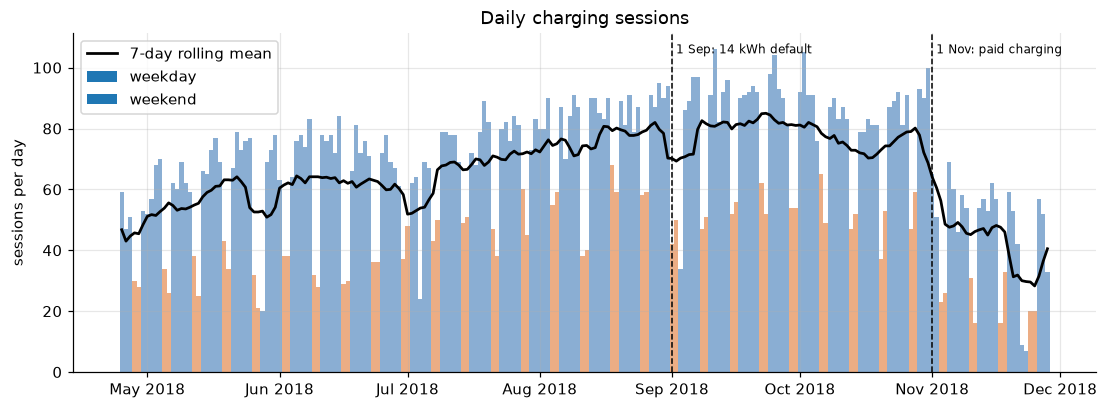

**Insight — Daily sessions over time.** Weekdays average 75 sessions vs 42 on weekends (1.8x). Weekday volume averages 74 (R1), 89 (R2) and 50 (R3, paid): -44% after paid charging began.

In [2]:
roll = daily.rolling(7, center=True, min_periods=4).mean()
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(daily.index, daily.values, width=1.0, color=np.where(daily.index.dayofweek >= 5, C_WE, C_WD), alpha=0.55)
ax.plot(roll.index, roll.values, color="k", lw=1.8, label="7-day rolling mean")
ax.bar([], [], color=C_WD, alpha=0.55, label="weekday"); ax.bar([], [], color=C_WE, alpha=0.55, label="weekend")
ax.set_title("Daily charging sessions"); ax.set_ylabel("sessions per day"); month_axis(ax); ax.legend(loc="upper left")
mark_policies(ax)

wd = daily[daily.index.dayofweek < 5]; we = daily[daily.index.dayofweek >= 5]
wd_reg = wd.groupby(day_regime.loc[wd.index]).mean().reindex(REGIMES)
insight = (f"Weekdays average {wd.mean():.0f} sessions vs {we.mean():.0f} on weekends ({wd.mean()/we.mean():.1f}x). "
           f"Weekday volume averages {wd_reg.iloc[0]:.0f} (R1), {wd_reg.iloc[1]:.0f} (R2) and {wd_reg.iloc[2]:.0f} (R3, paid): "
           f"{wd_reg.iloc[2]/wd_reg.iloc[1]-1:+.0%} after paid charging began.")
save(fig, "F01_daily_sessions", "Daily sessions over time", insight)

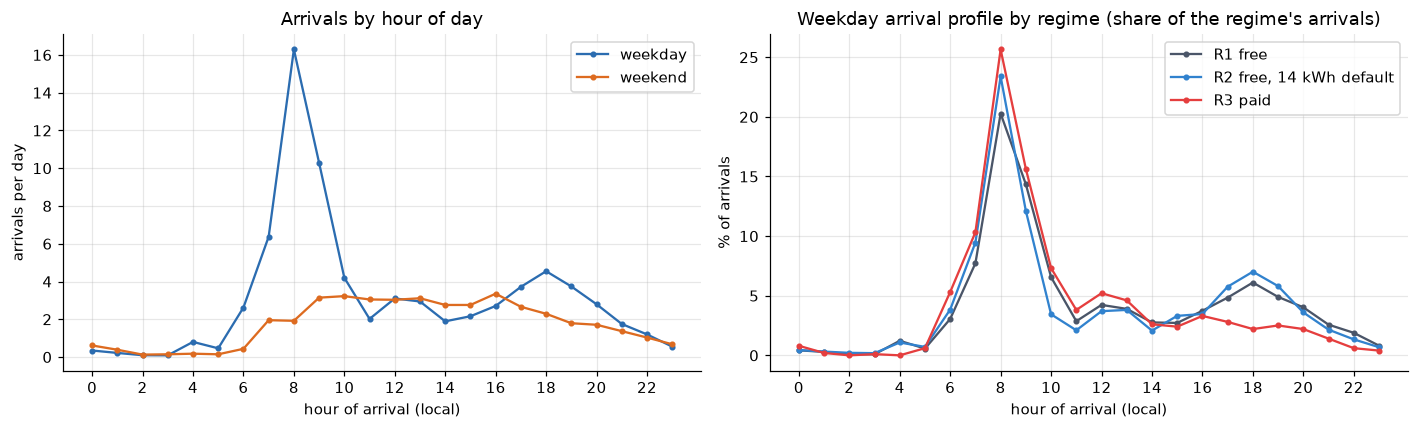

**Insight — Arrivals by hour of day.** Weekday arrivals peak at 8:00 (16.3 per day); 44% of weekday arrivals fall between 07:00 and 10:00. Weekend arrivals are flatter (peak-to-mean 1.9 vs 5.2 on weekdays). The 17:00–20:00 share of weekday arrivals is 16% in R1, 19% in R2, 8% in R3 — it falls under paid charging, consistent with the dataset authors' explanation that evening arrivals are price-sensitive community (non-campus) users.

In [3]:
n_wd = int((service_days.dayofweek < 5).sum()); n_we = int((service_days.dayofweek >= 5).sum())
arr_wd = df[~df.is_weekend].groupby("hour").size().reindex(range(24), fill_value=0) / n_wd
arr_we = df[df.is_weekend].groupby("hour").size().reindex(range(24), fill_value=0) / n_we

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].plot(arr_wd.index, arr_wd.values, "-o", ms=3, color=C_WD, label="weekday")
axs[0].plot(arr_we.index, arr_we.values, "-o", ms=3, color=C_WE, label="weekend")
axs[0].set(title="Arrivals by hour of day", xlabel="hour of arrival (local)", ylabel="arrivals per day", xticks=range(0, 24, 2)); axs[0].legend()

shape = {}
for rg in REGIMES:
    s = df[(~df.is_weekend) & (df["regime"] == rg)].groupby("hour").size().reindex(range(24), fill_value=0)
    if s.sum() > 0:
        shape[rg] = s / s.sum()
        axs[1].plot(range(24), shape[rg].values * 100, "-o", ms=3, color=REG_COLORS[rg], label=rg)
axs[1].set(title="Weekday arrival profile by regime (share of the regime's arrivals)", xlabel="hour of arrival (local)",
           ylabel="% of arrivals", xticks=range(0, 24, 2)); axs[1].legend()
fig.tight_layout()

pk = int(arr_wd.idxmax())
morning = arr_wd.loc[7:9].sum() / arr_wd.sum()
ev = {rg: shape[rg].loc[17:19].sum() for rg in shape}
we_peak_ratio = arr_we.max() / arr_we.mean() if arr_we.mean() else np.nan
wd_peak_ratio = arr_wd.max() / arr_wd.mean() if arr_wd.mean() else np.nan
ev_first, ev_last = ev[REGIMES[0]], ev.get(REGIMES[2], np.nan)
insight = (f"Weekday arrivals peak at {pk}:00 ({arr_wd.max():.1f} per day); {morning:.0%} of weekday arrivals fall between 07:00 and 10:00. "
           f"Weekend arrivals are {'flatter' if we_peak_ratio < wd_peak_ratio else 'no flatter'} (peak-to-mean {we_peak_ratio:.1f} vs {wd_peak_ratio:.1f} on weekdays). "
           f"The 17:00–20:00 share of weekday arrivals is "
           + ", ".join(f"{v:.0%} in {k.split()[0]}" for k, v in ev.items())
           + (" — it falls under paid charging, consistent with the dataset authors' explanation that evening arrivals are price-sensitive community (non-campus) users."
              if pd.notna(ev_last) and ev_last < 0.75 * ev_first else " — no clear change under paid charging."))
save(fig, "F02_arrivals_by_hour", "Arrivals by hour of day", insight)

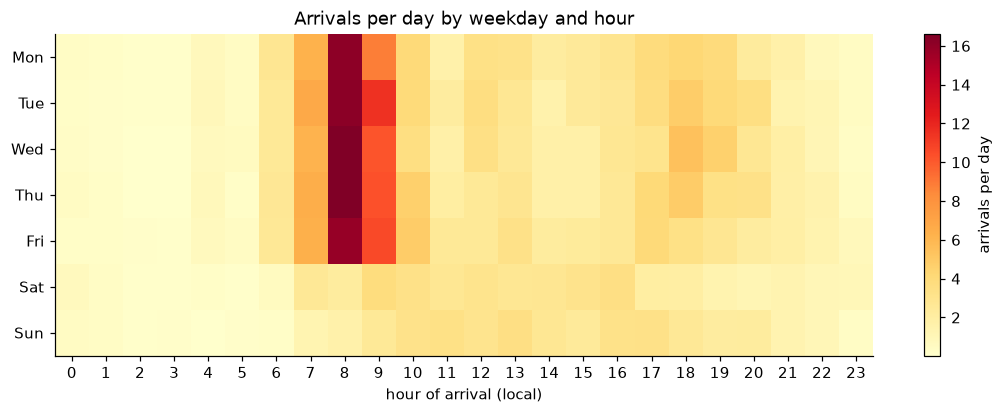

**Insight — Arrivals by weekday and hour.** The busiest cell is Wed 8:00 with 16.6 arrivals per day. Weekday peak hours are Mon 8:00, Tue 8:00, Wed 8:00, Thu 8:00, Fri 8:00 — the same morning pattern every working day; Saturday and Sunday peak at 3.7 arrivals per hour-slot.

In [4]:
n_by_dow = pd.Series(service_days.dayofweek).value_counts().reindex(range(7)).values
hm = df.groupby(["dayofweek", "hour"]).size().unstack(fill_value=0).reindex(index=range(7), columns=range(24), fill_value=0)
hm = hm.div(n_by_dow, axis=0)
fig, ax = plt.subplots(figsize=(12, 3.8))
im = ax.imshow(hm.values, aspect="auto", cmap="YlOrRd")
ax.set(yticks=range(7), yticklabels=DOW, xticks=range(24), xlabel="hour of arrival (local)", title="Arrivals per day by weekday and hour")
ax.grid(False); fig.colorbar(im, ax=ax, label="arrivals per day")
d_max, h_max = np.unravel_index(np.argmax(hm.values), hm.shape)
peak_hours = hm.loc[0:4].idxmax(axis=1)
same = peak_hours.max() - peak_hours.min() <= 1
insight = (f"The busiest cell is {DOW[d_max]} {h_max}:00 with {hm.values.max():.1f} arrivals per day. Weekday peak hours are "
           + ", ".join(f"{DOW[d]} {h}:00" for d, h in peak_hours.items())
           + (" — the same morning pattern every working day" if same else " — the peak shifts between weekdays")
           + f"; Saturday and Sunday peak at {hm.loc[5:6].values.max():.1f} arrivals per hour-slot.")
save(fig, "F03_arrival_heatmap", "Arrivals by weekday and hour", insight)

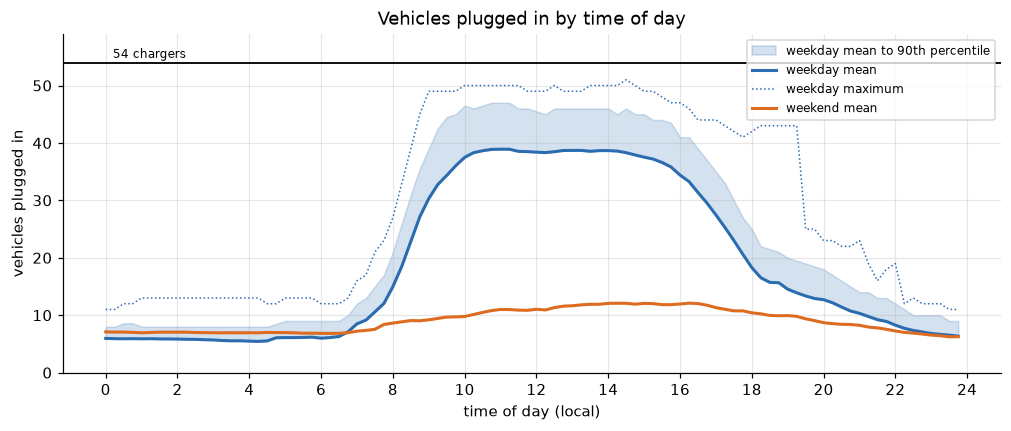

**Insight — Plugged-in vehicles by time of day.** On weekdays the number of plugged-in vehicles rises from about 6 overnight to a mean of 39 around 11:00 and stays high until mid-afternoon; the 90th percentile reaches 47 and the maximum 51 of 54 chargers. 5 of 156 weekdays reach ≥90% occupancy at some point, so capacity is tight only on the busiest days.

In [5]:
# Vehicles plugged in at the same time (15-minute resolution), weekdays, by time of day
occ = pd.concat([df[["connectionTime_loc", "disconnectTime_loc"]], long_sessions], ignore_index=True)
ev_s = pd.concat([pd.Series(1, index=occ["connectionTime_loc"].dt.floor("15min")),
                  pd.Series(-1, index=occ["disconnectTime_loc"].dt.floor("15min"))]).groupby(level=0).sum()
grid = pd.date_range(ev_s.index.min(), ev_s.index.max(), freq="15min")
plugged = ev_s.reindex(grid, fill_value=0).cumsum()
plugged = plugged[plugged.index.normalize().isin(service_days)]
pl = pd.DataFrame({"n": plugged.values, "tod": plugged.index.hour + plugged.index.minute / 60,
                   "wd": plugged.index.dayofweek < 5, "day": plugged.index.normalize()})
prof = pl[pl.wd].groupby("tod")["n"].agg(mean="mean", p90=lambda s: s.quantile(.9), mx="max")
prof_we = pl[~pl.wd].groupby("tod")["n"].mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(prof.index, prof["mean"], prof["p90"], color=C_WD, alpha=0.2, label="weekday mean to 90th percentile")
ax.plot(prof.index, prof["mean"], color=C_WD, lw=2, label="weekday mean")
ax.plot(prof.index, prof["mx"], color=C_WD, lw=1, ls=":", label="weekday maximum")
ax.plot(prof_we.index, prof_we.values, color=C_WE, lw=2, label="weekend mean")
ax.axhline(N_STATIONS, color="k", lw=1.2); ax.text(0.2, N_STATIONS + 0.8, f"{N_STATIONS} chargers", fontsize=8)
ax.set(title="Vehicles plugged in by time of day", xlabel="time of day (local)", ylabel="vehicles plugged in", xticks=range(0, 25, 2), ylim=(0, N_STATIONS + 5))
ax.legend(loc="upper right", fontsize=8)

wd_pl = pl[pl.wd]
full_days = wd_pl.loc[wd_pl["n"] >= 0.9 * N_STATIONS, "day"].nunique()
insight = (f"On weekdays the number of plugged-in vehicles rises from about {prof['mean'].iloc[0]:.0f} overnight to a mean of "
           f"{prof['mean'].max():.0f} around {int(prof['mean'].idxmax())}:00 and stays high until mid-afternoon; the 90th percentile reaches "
           f"{prof['p90'].max():.0f} and the maximum {int(prof['mx'].max())} of {N_STATIONS} chargers. {full_days} of "
           f"{wd_pl['day'].nunique()} weekdays reach ≥90% occupancy at some point"
           + (", so capacity is tight only on the busiest days." if full_days / max(wd_pl['day'].nunique(), 1) < 0.10
              else ", so capacity pressure is a regular weekday condition."))
save(fig, "F04_occupancy_profile", "Plugged-in vehicles by time of day", insight)

## 2. Energy consumption

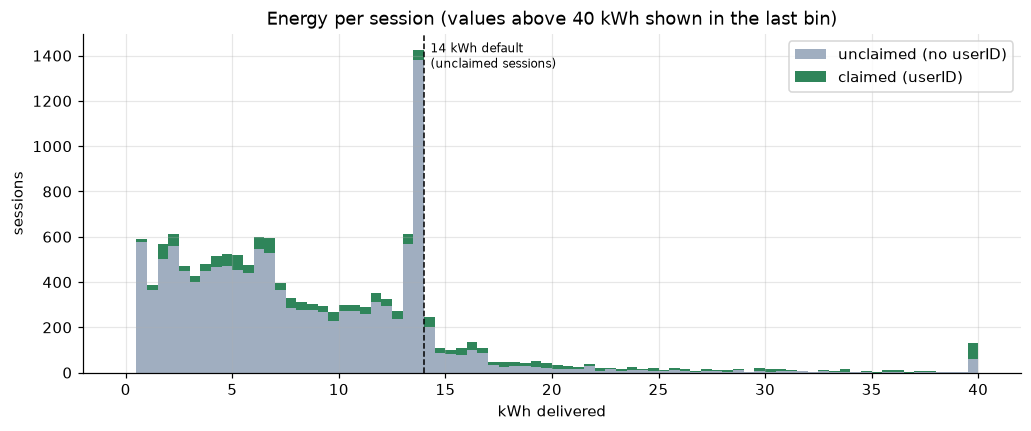

**Insight — Energy per session.** Median 7.5 kWh per session (mean 9.0): most sessions are well below a full battery. The 13–14 kWh bin holds 2,037 sessions, 4.5x its neighbours. During free charging (R1–R2), 16% of unclaimed sessions land in that bin vs 5% of claimed ones — consistent with the 14 kWh default allowance for unclaimed sessions (Issue #10, Section 7e).

In [6]:
bins = np.arange(0, 40.5, 0.5)
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist([df.loc[~df.claimed, "kWhDelivered"].clip(upper=40), df.loc[df.claimed, "kWhDelivered"].clip(upper=40)],
        bins=bins, stacked=True, color=[C_GREY, C_ACC], label=["unclaimed (no userID)", "claimed (userID)"])
ax.axvline(14, color="k", ls="--", lw=1); ax.text(14.3, ax.get_ylim()[1] * 0.9, "14 kWh default\n(unclaimed sessions)", fontsize=8)
ax.set(title="Energy per session (values above 40 kWh shown in the last bin)", xlabel="kWh delivered", ylabel="sessions"); ax.legend()

e = df["kWhDelivered"]
spike = e.between(13, 14, inclusive="left")
neigh = np.mean([e.between(a, a + 1, inclusive="left").sum() for a in (11, 12, 14, 15)])
free = df["regime"] != REGIMES[2]
rate_un = spike[free & ~df["claimed"]].mean()
rate_cl = spike[free & df["claimed"]].mean()
insight = (f"Median {e.median():.1f} kWh per session (mean {e.mean():.1f}): most sessions are well below a full battery. "
           f"The 13–14 kWh bin holds {spike.sum():,} sessions, {spike.sum()/neigh:.1f}x its neighbours. During free charging (R1–R2), "
           f"{rate_un:.0%} of unclaimed sessions land in that bin vs {rate_cl:.0%} of claimed ones"
           + (" — consistent with the 14 kWh default allowance for unclaimed sessions (Issue #10, Section 7e)." if rate_un > 2 * rate_cl
              else "; unclaimed sessions are not clearly over-represented, so this chart alone does not explain the spike."))
save(fig, "F05_energy_histogram", "Energy per session", insight)

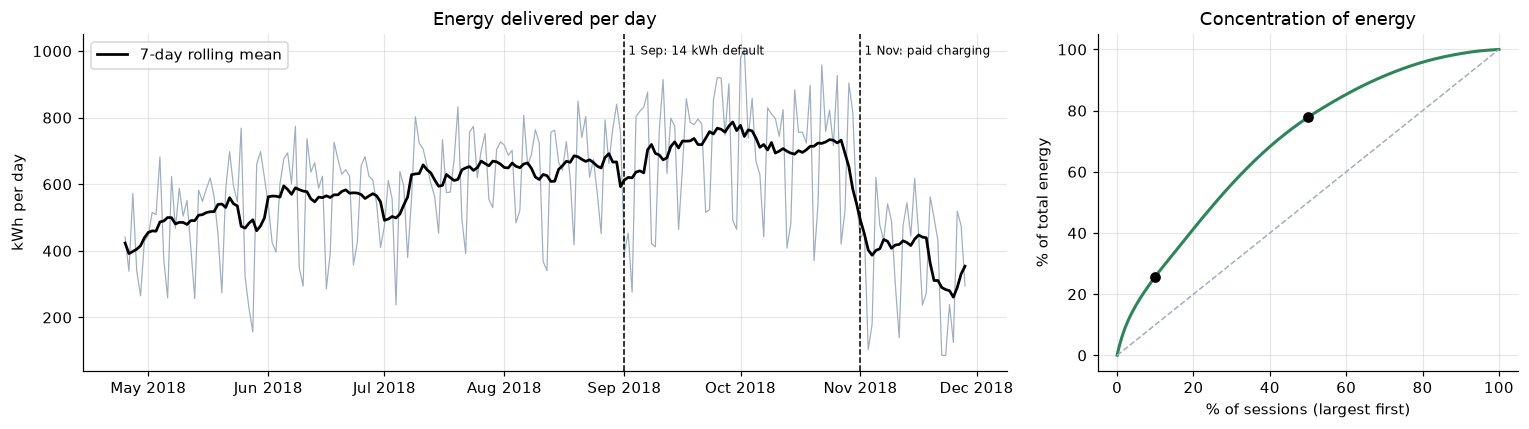

**Insight — Daily energy and energy concentration.** Energy delivered per day averages 577 kWh (R1), 707 kWh (R2) and 377 kWh (R3, paid), so daily load follows session volume. Energy is moderately concentrated: the largest 10% of sessions deliver 26% of all energy and the largest half 78%.

In [7]:
d_kwh = df.groupby("date")["kWhDelivered"].sum().reindex(service_days, fill_value=0)
fig, axs = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [2.2, 1]})
axs[0].plot(d_kwh.index, d_kwh.values, color=C_GREY, lw=0.8)
axs[0].plot(d_kwh.index, d_kwh.rolling(7, center=True, min_periods=4).mean(), color="k", lw=1.8, label="7-day rolling mean")
axs[0].set(title="Energy delivered per day", ylabel="kWh per day"); month_axis(axs[0]); axs[0].legend(loc="upper left"); mark_policies(axs[0])

s = np.sort(e.values)[::-1]
cum = np.cumsum(s) / s.sum(); x = np.arange(1, len(s) + 1) / len(s)
axs[1].plot(x * 100, cum * 100, color=C_ACC, lw=2); axs[1].plot([0, 100], [0, 100], color=C_GREY, ls="--", lw=1)
top10 = cum[int(len(s) * 0.10) - 1]; top50 = cum[int(len(s) * 0.50) - 1]
axs[1].scatter([10, 50], [top10 * 100, top50 * 100], color="k", zorder=3)
axs[1].set(title="Concentration of energy", xlabel="% of sessions (largest first)", ylabel="% of total energy")
fig.tight_layout()

kwh_reg = d_kwh.groupby(day_regime).mean().reindex(REGIMES)
insight = (f"Energy delivered per day averages {kwh_reg.iloc[0]:.0f} kWh (R1), {kwh_reg.iloc[1]:.0f} kWh (R2) and {kwh_reg.iloc[2]:.0f} kWh (R3, paid), "
           + (f"so daily load follows session volume. " if daily.corr(d_kwh) > 0.8 else f"(correlation with daily sessions {daily.corr(d_kwh):.2f}). ")
           + f"Energy is moderately concentrated: the largest 10% of sessions deliver {top10:.0%} "
           f"of all energy and the largest half {top50:.0%}.")
save(fig, "F06_daily_energy_and_concentration", "Daily energy and energy concentration", insight)

## 3. Charging duration

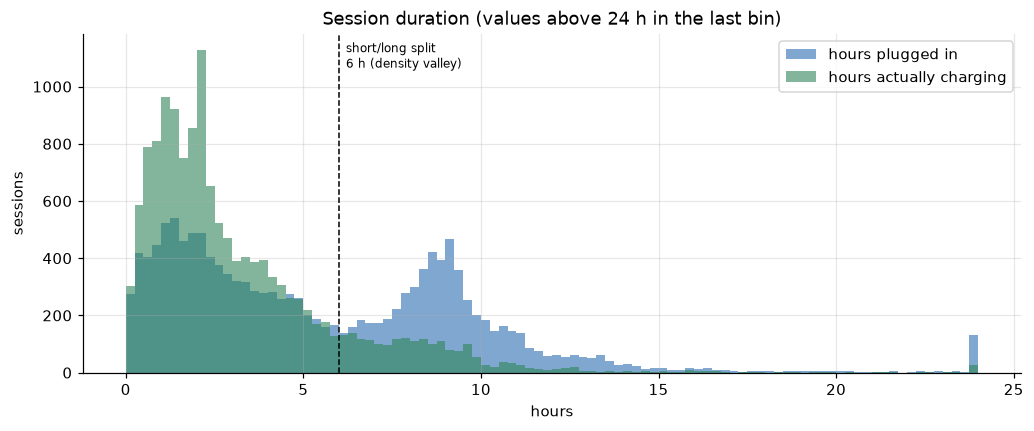

**Insight — Session duration.** Plugged-in time has two modes, short visits and full-workday stays, separated at about 6.1 h; 43% of sessions are long stays. Charging itself is much shorter (median 2.3 h vs 4.7 h plugged in), so 44% of plugged-in hours are idle — a car occupying a charger without drawing power.

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
b = np.arange(0, 24.25, 0.25)
ax.hist(df["connected_h"].clip(upper=24), bins=b, alpha=0.6, color=C_WD, label="hours plugged in")
ax.hist(df.loc[df.done_ok, "charging_h"].clip(upper=24), bins=b, alpha=0.6, color=C_ACC, label="hours actually charging")
ax.axvline(SHORT_STAY_H, color="k", ls="--", lw=1)
ax.text(SHORT_STAY_H + 0.2, ax.get_ylim()[1] * 0.9, f"short/long split\n{SHORT_STAY_H:g} h (density valley)", fontsize=8)
ax.set(title="Session duration (values above 24 h in the last bin)", xlabel="hours", ylabel="sessions"); ax.legend()

ok = df[df.done_ok]
idle_share = ok["idle_h"].sum() / ok["connected_h"].sum()
insight = (f"Plugged-in time has two modes, short visits and full-workday stays, separated at about {valley_h:.1f} h; "
           f"{(df['connected_h'] >= SHORT_STAY_H).mean():.0%} of sessions are long stays. Charging itself is much shorter "
           f"(median {ok['charging_h'].median():.1f} h vs {df['connected_h'].median():.1f} h plugged in), so {idle_share:.0%} of plugged-in hours are idle — "
           f"a car occupying a charger without drawing power.")
save(fig, "F07_duration_histogram", "Session duration", insight)

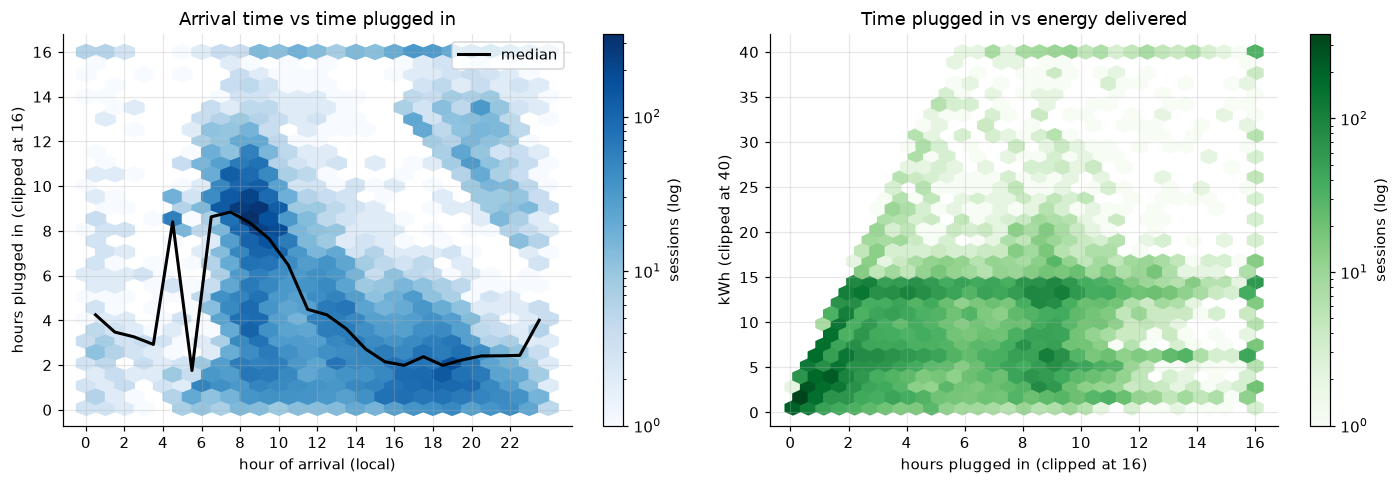

**Insight — Arrival time, stay length and energy.** Arrival time and stay length have a moderate negative relationship (Spearman rho -0.37): arrivals at 07:00–10:00 stay a median 8.2 h, arrivals at 17:00–20:00 2.2 h. Energy and stay length have a moderate relationship (rho 0.42) — energy grows far less than stay length, so long stays are mostly parking time, which is what makes them schedulable.

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
hb = axs[0].hexbin(df["hour"] + df["connectionTime_loc"].dt.minute / 60, df["connected_h"].clip(upper=16), gridsize=(24, 16),
                   cmap="Blues", mincnt=1, bins="log")
med = df.groupby("hour")["connected_h"].median()
axs[0].plot(med.index + 0.5, med.values, color="k", lw=2, label="median")
axs[0].set(title="Arrival time vs time plugged in", xlabel="hour of arrival (local)", ylabel="hours plugged in (clipped at 16)", xticks=range(0, 24, 2))
axs[0].legend(); fig.colorbar(hb, ax=axs[0], label="sessions (log)")

hb2 = axs[1].hexbin(df["connected_h"].clip(upper=16), df["kWhDelivered"].clip(upper=40), gridsize=30, cmap="Greens", mincnt=1, bins="log")
axs[1].set(title="Time plugged in vs energy delivered", xlabel="hours plugged in (clipped at 16)", ylabel="kWh (clipped at 40)")
fig.colorbar(hb2, ax=axs[1], label="sessions (log)"); fig.tight_layout()

rho_ad = df[["hour", "connected_h"]].corr(method="spearman").iloc[0, 1]
rho_ed = df[["kWhDelivered", "connected_h"]].corr(method="spearman").iloc[0, 1]
m_morn = df.loc[df.hour.between(7, 9), "connected_h"].median(); m_eve = df.loc[df.hour.between(17, 19), "connected_h"].median()
insight = (f"Arrival time and stay length have a {strength(rho_ad)} {'negative' if rho_ad < 0 else 'positive'} relationship (Spearman rho {rho_ad:.2f}): "
           f"arrivals at 07:00–10:00 stay a median {m_morn:.1f} h, arrivals at 17:00–20:00 {m_eve:.1f} h. "
           f"Energy and stay length have a {strength(rho_ed)} relationship (rho {rho_ed:.2f})"
           + (" — energy grows far less than stay length, so long stays are mostly parking time, which is what makes them schedulable."
              if 0 < rho_ed < 0.6 else "."))
save(fig, "F08_arrival_duration_energy", "Arrival time, stay length and energy", insight)

## 4. Station utilization

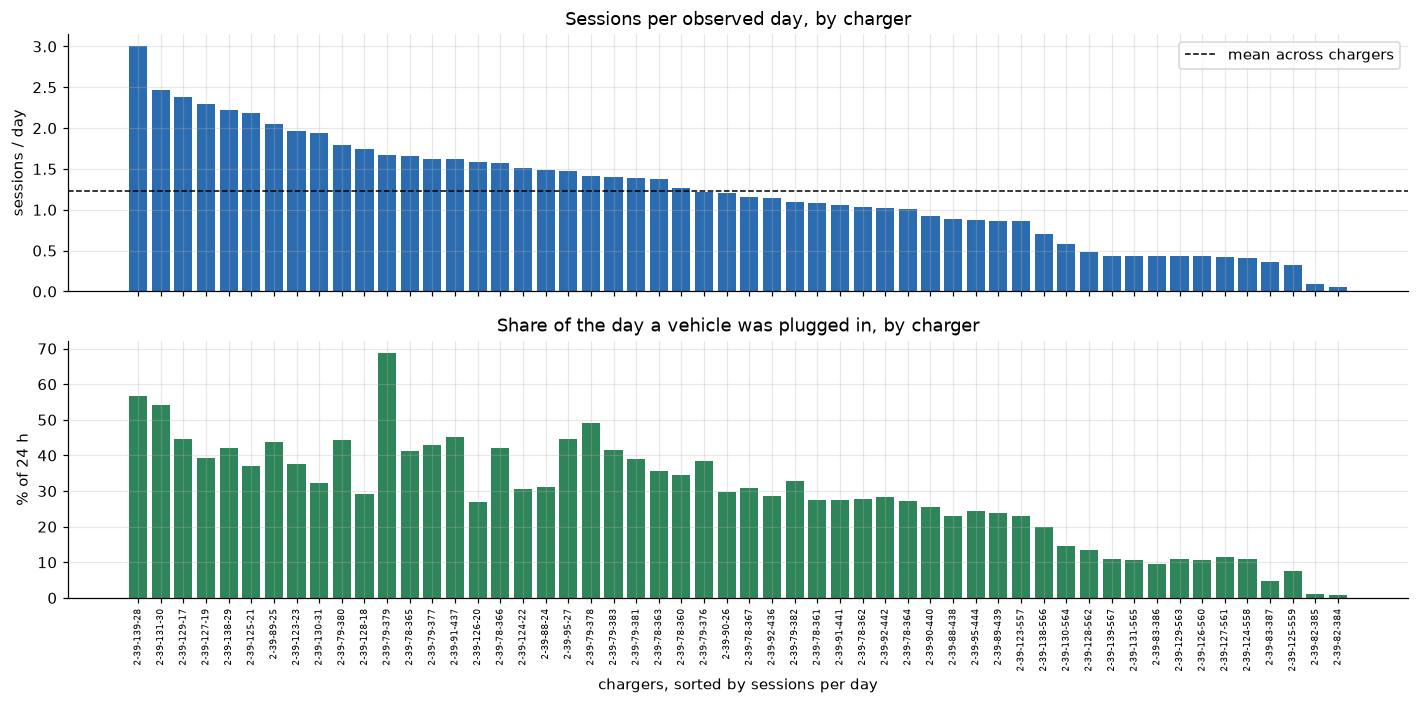

**Insight — Utilization by charger.** Use is uneven but not extreme (Gini 0.31 on sessions): the busiest charger averages 3.0 sessions per day, the quietest 0.1. Occupancy ranges from 1% to 69% of the clock (median 29%). The rank correlation between sessions per day and occupancy is 0.90, so session counts are a fair guide to occupancy.

In [10]:
stn = df.groupby("stationID").agg(sessions=("_id", "count"), kwh=("kWhDelivered", "sum"), plugged_h=("connected_h", "sum"),
                                  first=("date", "min"), last=("date", "max"))
stn["observed_days"] = (stn["last"] - stn["first"]).dt.days + 1
stn["sessions_per_day"] = stn["sessions"] / stn["observed_days"]
stn["occupied_share"] = stn["plugged_h"] / (stn["observed_days"] * 24)      # share of the clock the charger had a car plugged in
stn = stn.sort_values("sessions_per_day", ascending=False)

fig, axs = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
axs[0].bar(range(len(stn)), stn["sessions_per_day"], color=C_WD)
axs[0].axhline(stn["sessions_per_day"].mean(), color="k", ls="--", lw=1, label="mean across chargers")
axs[0].set(title="Sessions per observed day, by charger", ylabel="sessions / day"); axs[0].legend()
axs[1].bar(range(len(stn)), stn["occupied_share"] * 100, color=C_ACC)
axs[1].set(title="Share of the day a vehicle was plugged in, by charger", ylabel="% of 24 h", xlabel="chargers, sorted by sessions per day")
axs[1].set_xticks(range(len(stn))); axs[1].set_xticklabels(stn.index, rotation=90, fontsize=6)
fig.tight_layout()

x = np.sort(stn["sessions"].values); n = len(x)
gini = float((2 * np.arange(1, n + 1) - n - 1).dot(x) / (n * x.sum()))
insight = (f"Use is uneven but not extreme (Gini {gini:.2f} on sessions): the busiest charger averages {stn['sessions_per_day'].max():.1f} sessions per day, "
           f"the quietest {stn['sessions_per_day'].min():.1f}. Occupancy ranges from {stn['occupied_share'].min():.0%} to {stn['occupied_share'].max():.0%} "
           f"of the clock (median {stn['occupied_share'].median():.0%}). The rank correlation between sessions per day and occupancy is "
           f"{stn[['sessions_per_day','occupied_share']].corr(method='spearman').iloc[0,1]:.2f}"
           + (", so session counts alone are a poor guide to how occupied a charger is." if stn[['sessions_per_day','occupied_share']].corr(method='spearman').iloc[0,1] < 0.6
              else ", so session counts are a fair guide to occupancy."))
save(fig, "F09_station_utilization", "Utilization by charger", insight)

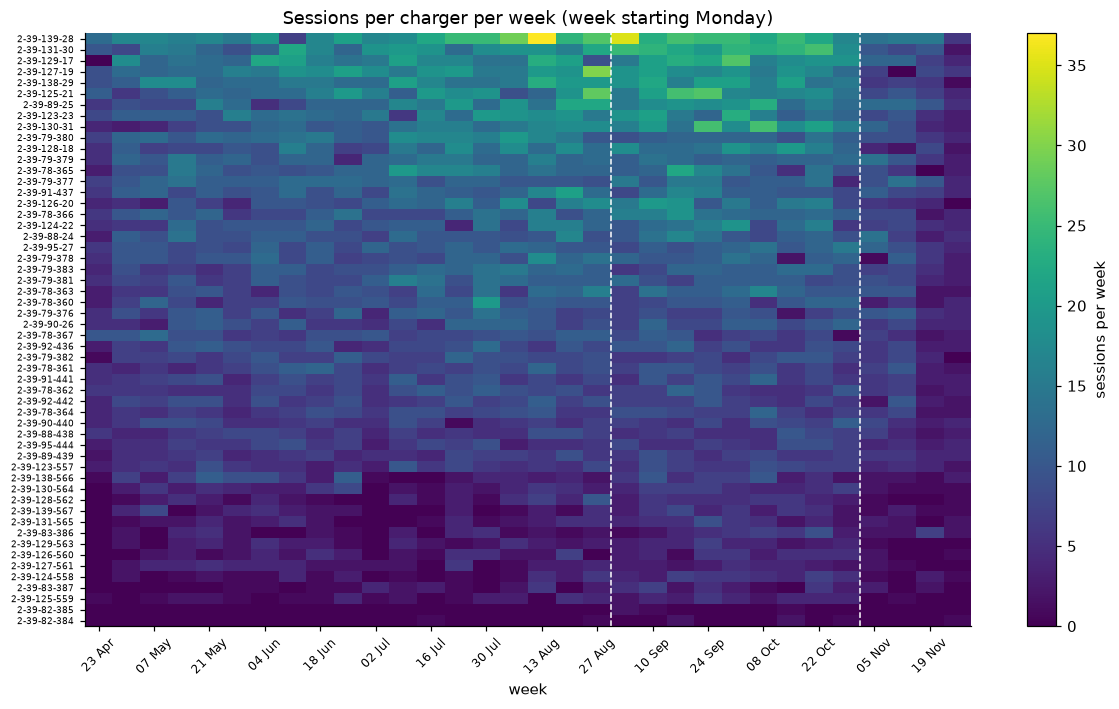

**Insight — Sessions per charger per week.** 38 of 54 chargers have sessions in every complete week; 16 have at least one empty week (107 charger-weeks in total), which more likely marks a fault or out-of-service period than zero demand — worth checking before using per-charger rates. After 1 Nov, 53 of 54 chargers average fewer sessions per week than in Sep–Oct, so the drop is network-wide.

In [11]:
df["week"] = df["date"] - pd.to_timedelta(df["dayofweek"], unit="D")
sw = df.groupby(["stationID", "week"]).size().unstack(fill_value=0)
sw = sw.reindex(stn.index)                                            # same order as F09
weeks = sw.columns
fig, ax = plt.subplots(figsize=(13, 7))
im = ax.imshow(sw.values, aspect="auto", cmap="viridis", interpolation="nearest")
ax.set_yticks(range(len(sw))); ax.set_yticklabels(sw.index, fontsize=6)
step = max(1, len(weeks) // 12)
ax.set_xticks(range(0, len(weeks), step)); ax.set_xticklabels([w.strftime("%d %b") for w in weeks[::step]], rotation=45, fontsize=8)
for d in POLICY_DATES:
    pos = np.searchsorted(weeks, d)
    if 0 < pos < len(weeks): ax.axvline(pos - 0.5, color="w", ls="--", lw=1)
ax.set(title="Sessions per charger per week (week starting Monday)", xlabel="week"); ax.grid(False)
fig.colorbar(im, ax=ax, label="sessions per week")

inner = sw.iloc[:, 1:-1]                                              # drop partial first/last week
zero_weeks = (inner == 0).sum(axis=1)
pre_w = inner.loc[:, (inner.columns >= POLICY_DATES[0]) & (inner.columns < POLICY_DATES[1])].mean(axis=1)
post_w = inner.loc[:, inner.columns >= POLICY_DATES[1]].mean(axis=1)
n_lower = int((post_w < pre_w).sum()) if post_w.notna().any() else 0
insight = (f"{int((zero_weeks == 0).sum())} of {len(sw)} chargers have sessions in every complete week; {int((zero_weeks > 0).sum())} have at least one empty week"
           + (f" ({int(zero_weeks.sum())} charger-weeks in total), which more likely marks a fault or out-of-service period than zero demand — worth checking "
              f"before using per-charger rates." if zero_weeks.sum() else ".")
           + (f" After 1 Nov, {n_lower} of {int(post_w.notna().sum())} chargers average fewer sessions per week than in Sep–Oct, so the drop is "
              f"{'network-wide' if n_lower >= 0.8 * post_w.notna().sum() else 'concentrated at some chargers'}." if post_w.notna().any() else ""))
save(fig, "F10_station_week_heatmap", "Sessions per charger per week", insight)

## 5. Distributions

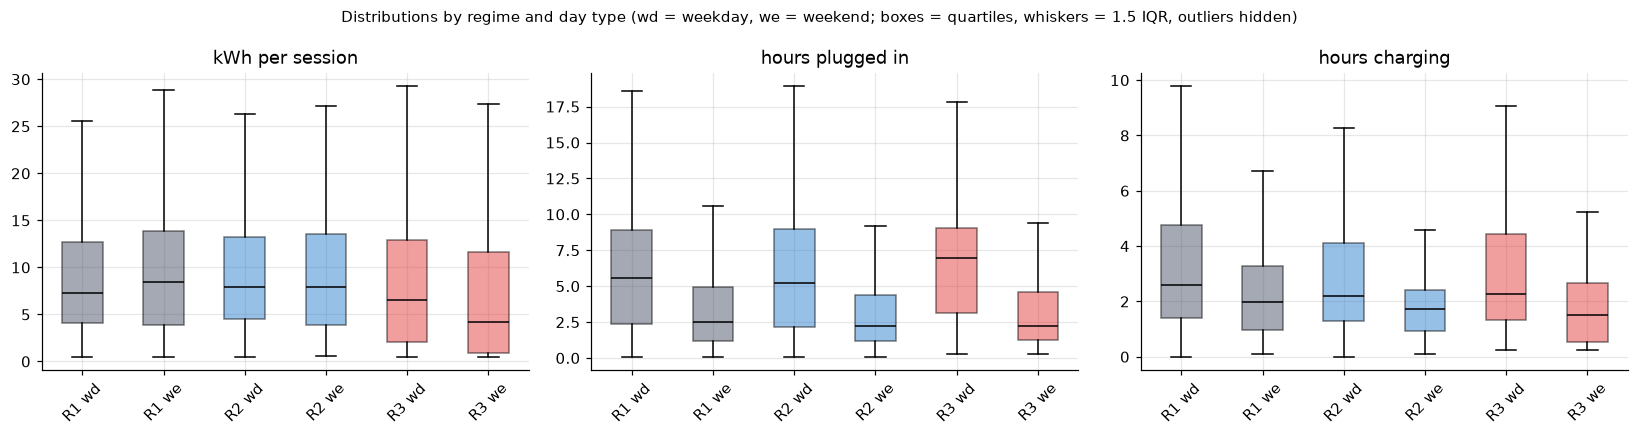

**Insight — Distributions by regime and day type.** In R1, weekend stays have a median of 2.5 h vs 5.6 h on weekdays, with 8.5 vs 7.3 kWh per session; weekend drivers stay much shorter for the same or more energy, i.e. they come to charge rather than to park for work. Under paid charging, weekday sessions have a median of 6.9 h and 6.5 kWh (R1: 5.6 h, 7.3 kWh); longer stays with less energy fit the loss of short community visits and the 30-minute cut-off for unclaimed sessions.

In [12]:
groups, labels, colors = [], [], []
for rg in REGIMES:
    for we, lab in [(False, "wd"), (True, "we")]:
        sub = df[(df["regime"] == rg) & (df["is_weekend"] == we)]
        if len(sub):
            groups.append(sub); labels.append(f"{rg.split()[0]} {lab}"); colors.append(REG_COLORS[rg])
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, ttl in zip(axs, ["kWhDelivered", "connected_h", "charging_h"], ["kWh per session", "hours plugged in", "hours charging"]):
    bp = ax.boxplot([g[col].dropna() for g in groups], tick_labels=labels, showfliers=False, patch_artist=True, medianprops={"color": "k"})
    for p, c in zip(bp["boxes"], colors): p.set_facecolor(c); p.set_alpha(0.5)
    ax.set(title=ttl); ax.tick_params(axis="x", rotation=45)
fig.suptitle("Distributions by regime and day type (wd = weekday, we = weekend; boxes = quartiles, whiskers = 1.5 IQR, outliers hidden)", fontsize=10)
fig.tight_layout()

med = df.groupby(["regime", "is_weekend"], observed=True)[["kWhDelivered", "connected_h"]].median()
r1wd, r1we = med.loc[(REGIMES[0], False)], med.loc[(REGIMES[0], True)]
r3wd = med.loc[(REGIMES[2], False)] if (REGIMES[2], False) in med.index else None
shorter_we = r1we["connected_h"] < 0.75 * r1wd["connected_h"]
similar_kwh = r1we["kWhDelivered"] >= 0.8 * r1wd["kWhDelivered"]
insight = (f"In R1, weekend stays have a median of {r1we['connected_h']:.1f} h vs {r1wd['connected_h']:.1f} h on weekdays, with {r1we['kWhDelivered']:.1f} vs "
           f"{r1wd['kWhDelivered']:.1f} kWh per session"
           + ("; weekend drivers stay much shorter for the same or more energy, i.e. they come to charge rather than to park for work. " if shorter_we and similar_kwh else ". ")
           + (f"Under paid charging, weekday sessions have a median of {r3wd['connected_h']:.1f} h and {r3wd['kWhDelivered']:.1f} kWh "
              f"(R1: {r1wd['connected_h']:.1f} h, {r1wd['kWhDelivered']:.1f} kWh)"
              + ("; longer stays with less energy fit the loss of short community visits and the 30-minute cut-off for unclaimed sessions."
                 if r3wd['connected_h'] > r1wd['connected_h'] and r3wd['kWhDelivered'] < r1wd['kWhDelivered'] else ".")
              if r3wd is not None else ""))
save(fig, "F11_distributions_by_regime", "Distributions by regime and day type", insight)

## 6. Comparing important charging patterns

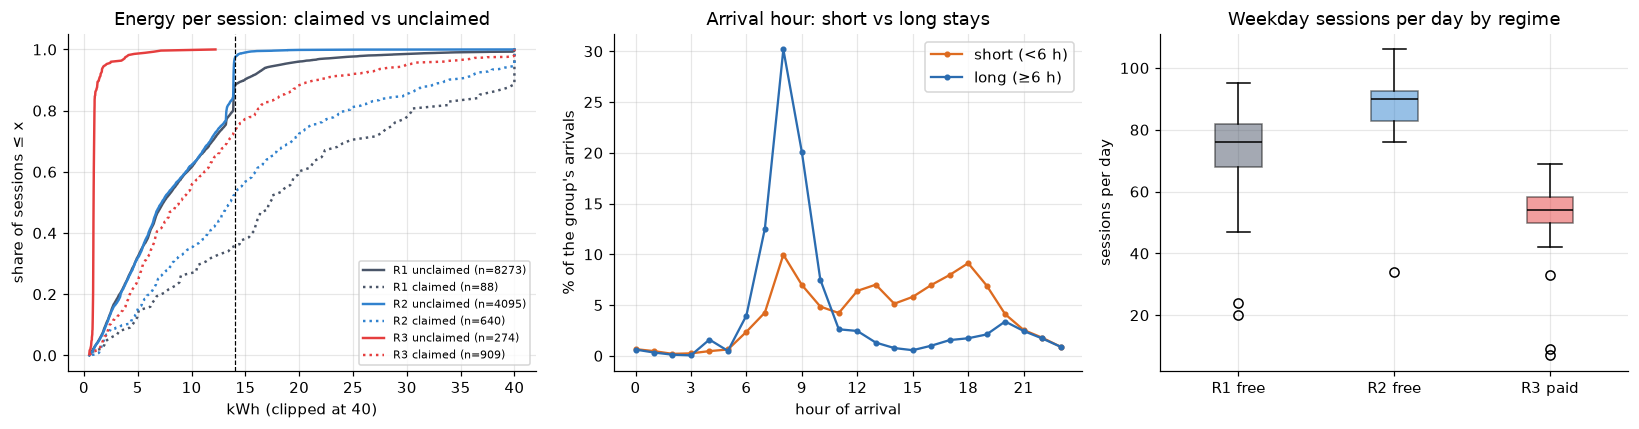

**Insight — Claimed vs unclaimed, short vs long, free vs paid.** (1) Median energy of unclaimed sessions is 7.4 kWh in R1, 7.2 kWh in R2, 0.9 kWh in R3; it collapses when the 30-minute cut-off starts, so energy for unclaimed sessions reflects the operator's rules, not drivers' need. (2) 63% of long stays arrive 07:00–10:00 vs 21% of short stays; long stays are morning commuters, short stays arrive across the day. (3) Weekday volume goes from a median of 90 sessions per day in R2 to 54 in R3.

In [13]:
def ecdf(ax, s, **kw):
    s = np.sort(s.dropna().values); ax.plot(s, np.arange(1, len(s) + 1) / len(s), **kw)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for rg in REGIMES:
    for cl, ls in [(False, "-"), (True, ":")]:
        sub = df[(df["regime"] == rg) & (df["claimed"] == cl)]["kWhDelivered"]
        if len(sub) >= 30:
            ecdf(axs[0], sub.clip(upper=40), color=REG_COLORS[rg], ls=ls, lw=1.6, label=f"{rg.split()[0]} {'claimed' if cl else 'unclaimed'} (n={len(sub)})")
axs[0].axvline(14, color="k", lw=0.8, ls="--")
axs[0].set(title="Energy per session: claimed vs unclaimed", xlabel="kWh (clipped at 40)", ylabel="share of sessions ≤ x"); axs[0].legend(fontsize=7)

sd = df[df["connected_h"] < SHORT_STAY_H]; lg = df[df["connected_h"] >= SHORT_STAY_H]
for sub, c, lab in [(sd, C_WE, f"short (<{SHORT_STAY_H:g} h)"), (lg, C_WD, f"long (≥{SHORT_STAY_H:g} h)")]:
    a = sub.groupby("hour").size().reindex(range(24), fill_value=0)
    axs[1].plot(range(24), a / a.sum() * 100, "-o", ms=3, color=c, label=lab)
axs[1].set(title="Arrival hour: short vs long stays", xlabel="hour of arrival", ylabel="% of the group's arrivals", xticks=range(0, 24, 3)); axs[1].legend()

wdd = daily[daily.index.dayofweek < 5]
data = [wdd[day_regime.loc[wdd.index] == rg].values for rg in REGIMES]
bp = axs[2].boxplot(data, tick_labels=[r.split(",")[0] for r in REGIMES], patch_artist=True, medianprops={"color": "k"})
for p, rg in zip(bp["boxes"], REGIMES): p.set_facecolor(REG_COLORS[rg]); p.set_alpha(0.5)
axs[2].set(title="Weekday sessions per day by regime", ylabel="sessions per day")
fig.tight_layout()

un = df[~df.claimed].groupby("regime", observed=True)["kWhDelivered"].median()
policy_driven = (REGIMES[2] in un.index) and un[REGIMES[2]] < 0.5 * un[REGIMES[1]]
morn_l, morn_s = lg["hour"].between(7, 9).mean(), sd["hour"].between(7, 9).mean()
insight = (f"(1) Median energy of unclaimed sessions is "
           + ", ".join(f"{un[rg]:.1f} kWh in {rg.split()[0]}" for rg in un.index)
           + ("; it collapses when the 30-minute cut-off starts, so energy for unclaimed sessions reflects the operator's rules, not drivers' need. " if policy_driven else ". ")
           + f"(2) {morn_l:.0%} of long stays arrive 07:00–10:00 vs {morn_s:.0%} of short stays"
           + ("; long stays are morning commuters, short stays arrive across the day. " if morn_l > 1.5 * morn_s else ". ")
           + f"(3) Weekday volume goes from a median of {np.median(data[1]):.0f} sessions per day in R2 to {np.median(data[2]) if len(data[2]) else float('nan'):.0f} in R3.")
save(fig, "F12_pattern_comparisons", "Claimed vs unclaimed, short vs long, free vs paid", insight)

## 7. Interpretation of major findings

In [14]:
lines = ["# EDA visual insights (generated from the data)", "",
         f"Data: {len(df):,} sessions at {N_STATIONS} chargers, {service_days.min().date()} to {service_days.max().date()} ({len(service_days)} days with data). "
         "Figures are in `eda_figures/`; statistical tables and tests are in Issue #10 (`eda_tables/`, `eda_key_findings.md`).", "",
         "| Figure | Topic | Insight |", "|---|---|---|"]
lines += [f"| `{n}.png` | {t} | {i} |" for n, t, i in INSIGHTS]
lines += ["", "## Caveats for the modelling stage",
          "- The window contains two documented policy changes (1 Sep and 1 Nov 2018). Pooled charts mix them; models should use one regime or include the regime as a feature.",
          f"- The paid period (R3) covers only {int((day_regime == REGIMES[2]).sum())} days with data, so paid-period patterns are indicative.",
          "- Energy for unclaimed sessions is shaped by default allowances, so it is not a direct measure of drivers' energy need.",
          "- There is no full annual cycle; seasonality cannot be read from these charts."]
text = "\n".join(lines) + "\n"
with open("eda_visual_insights.md", "w", encoding="utf-8") as fh:
    fh.write(text)
display(Markdown(text))
print("Figures saved:", sorted(os.listdir(FIG_DIR)))

# EDA visual insights (generated from the data)

Data: 14,279 sessions at 54 chargers, 2018-04-25 to 2018-11-28 (218 days with data). Figures are in `eda_figures/`; statistical tables and tests are in Issue #10 (`eda_tables/`, `eda_key_findings.md`).

| Figure | Topic | Insight |
|---|---|---|
| `F01_daily_sessions.png` | Daily sessions over time | Weekdays average 75 sessions vs 42 on weekends (1.8x). Weekday volume averages 74 (R1), 89 (R2) and 50 (R3, paid): -44% after paid charging began. |
| `F02_arrivals_by_hour.png` | Arrivals by hour of day | Weekday arrivals peak at 8:00 (16.3 per day); 44% of weekday arrivals fall between 07:00 and 10:00. Weekend arrivals are flatter (peak-to-mean 1.9 vs 5.2 on weekdays). The 17:00–20:00 share of weekday arrivals is 16% in R1, 19% in R2, 8% in R3 — it falls under paid charging, consistent with the dataset authors' explanation that evening arrivals are price-sensitive community (non-campus) users. |
| `F03_arrival_heatmap.png` | Arrivals by weekday and hour | The busiest cell is Wed 8:00 with 16.6 arrivals per day. Weekday peak hours are Mon 8:00, Tue 8:00, Wed 8:00, Thu 8:00, Fri 8:00 — the same morning pattern every working day; Saturday and Sunday peak at 3.7 arrivals per hour-slot. |
| `F04_occupancy_profile.png` | Plugged-in vehicles by time of day | On weekdays the number of plugged-in vehicles rises from about 6 overnight to a mean of 39 around 11:00 and stays high until mid-afternoon; the 90th percentile reaches 47 and the maximum 51 of 54 chargers. 5 of 156 weekdays reach ≥90% occupancy at some point, so capacity is tight only on the busiest days. |
| `F05_energy_histogram.png` | Energy per session | Median 7.5 kWh per session (mean 9.0): most sessions are well below a full battery. The 13–14 kWh bin holds 2,037 sessions, 4.5x its neighbours. During free charging (R1–R2), 16% of unclaimed sessions land in that bin vs 5% of claimed ones — consistent with the 14 kWh default allowance for unclaimed sessions (Issue #10, Section 7e). |
| `F06_daily_energy_and_concentration.png` | Daily energy and energy concentration | Energy delivered per day averages 577 kWh (R1), 707 kWh (R2) and 377 kWh (R3, paid), so daily load follows session volume. Energy is moderately concentrated: the largest 10% of sessions deliver 26% of all energy and the largest half 78%. |
| `F07_duration_histogram.png` | Session duration | Plugged-in time has two modes, short visits and full-workday stays, separated at about 6.1 h; 43% of sessions are long stays. Charging itself is much shorter (median 2.3 h vs 4.7 h plugged in), so 44% of plugged-in hours are idle — a car occupying a charger without drawing power. |
| `F08_arrival_duration_energy.png` | Arrival time, stay length and energy | Arrival time and stay length have a moderate negative relationship (Spearman rho -0.37): arrivals at 07:00–10:00 stay a median 8.2 h, arrivals at 17:00–20:00 2.2 h. Energy and stay length have a moderate relationship (rho 0.42) — energy grows far less than stay length, so long stays are mostly parking time, which is what makes them schedulable. |
| `F09_station_utilization.png` | Utilization by charger | Use is uneven but not extreme (Gini 0.31 on sessions): the busiest charger averages 3.0 sessions per day, the quietest 0.1. Occupancy ranges from 1% to 69% of the clock (median 29%). The rank correlation between sessions per day and occupancy is 0.90, so session counts are a fair guide to occupancy. |
| `F10_station_week_heatmap.png` | Sessions per charger per week | 38 of 54 chargers have sessions in every complete week; 16 have at least one empty week (107 charger-weeks in total), which more likely marks a fault or out-of-service period than zero demand — worth checking before using per-charger rates. After 1 Nov, 53 of 54 chargers average fewer sessions per week than in Sep–Oct, so the drop is network-wide. |
| `F11_distributions_by_regime.png` | Distributions by regime and day type | In R1, weekend stays have a median of 2.5 h vs 5.6 h on weekdays, with 8.5 vs 7.3 kWh per session; weekend drivers stay much shorter for the same or more energy, i.e. they come to charge rather than to park for work. Under paid charging, weekday sessions have a median of 6.9 h and 6.5 kWh (R1: 5.6 h, 7.3 kWh); longer stays with less energy fit the loss of short community visits and the 30-minute cut-off for unclaimed sessions. |
| `F12_pattern_comparisons.png` | Claimed vs unclaimed, short vs long, free vs paid | (1) Median energy of unclaimed sessions is 7.4 kWh in R1, 7.2 kWh in R2, 0.9 kWh in R3; it collapses when the 30-minute cut-off starts, so energy for unclaimed sessions reflects the operator's rules, not drivers' need. (2) 63% of long stays arrive 07:00–10:00 vs 21% of short stays; long stays are morning commuters, short stays arrive across the day. (3) Weekday volume goes from a median of 90 sessions per day in R2 to 54 in R3. |

## Caveats for the modelling stage
- The window contains two documented policy changes (1 Sep and 1 Nov 2018). Pooled charts mix them; models should use one regime or include the regime as a feature.
- The paid period (R3) covers only 28 days with data, so paid-period patterns are indicative.
- Energy for unclaimed sessions is shaped by default allowances, so it is not a direct measure of drivers' energy need.
- There is no full annual cycle; seasonality cannot be read from these charts.


Figures saved: ['F01_daily_sessions.png', 'F02_arrivals_by_hour.png', 'F03_arrival_heatmap.png', 'F04_occupancy_profile.png', 'F05_energy_histogram.png', 'F06_daily_energy_and_concentration.png', 'F07_duration_histogram.png', 'F08_arrival_duration_energy.png', 'F09_station_utilization.png', 'F10_station_week_heatmap.png', 'F11_distributions_by_regime.png', 'F12_pattern_comparisons.png']


## Issue #11 checklist → where it is done

| Task | Figures |
|---|---|
| Create time-based demand visualizations | F01, F02, F03, F04, F06 (left) |
| Visualize energy consumption | F05, F06 |
| Visualize charging duration | F07, F08 |
| Visualize station/site utilization | F09, F10 (one site only, so utilization is shown per charger) |
| Visualize relevant distributions | F05, F07, F11 |
| Compare important charging patterns | F02 (right), F11, F12 |
| Document insights from each major visualization | Insight under every figure; `eda_visual_insights.md` |

**Deliverables:** this notebook (with outputs saved), the `eda_figures/` folder, and `eda_visual_insights.md`.